In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

In [2]:
def qft_on(circ: QuantumCircuit, qubits):
    n = len(qubits)
    for j in range(n):
        qj = qubits[j]
        circ.h(qj)
        for k in range(j + 1, n):
            qk = qubits[k]
            angle = np.pi / (2 ** (k - j))
            circ.cp(angle, qk, qj)
    # bit reversal
    for j in range(n // 2):
        circ.swap(qubits[j], qubits[n - 1 - j])

In [3]:
def iqft_on(circ: QuantumCircuit, qubits):
    n = len(qubits)
    # undo bit-reversal first
    for j in range(n // 2):
        circ.swap(qubits[j], qubits[n - 1 - j])

    # inverse rotations
    for j in reversed(range(n)):
        qj = qubits[j]
        for k in reversed(range(j + 1, n)):
            qk = qubits[k]
            angle = -np.pi / (2 ** (k - j))  # negative angle
            circ.cp(angle, qk, qj)
        circ.h(qj)

In [4]:
def add_classical_constant_on(circ: QuantumCircuit, qubits, a: int):
    """
    |x> → |x + a (mod 2^n)> 구현 (Draper adder)
    qubits: MSB → LSB 순서 (예: [0,1,2…])
    a: 더할 classical integer
    """

    n = len(qubits)
    # 1. QFT
    qft_on(circ, qubits)

    # 2. phase rotations
    for j, qj in enumerate(qubits):
        theta = +2 * np.pi * a / (2 ** (j + 1))
        circ.p(theta, qj)

    # 3. iQFT
    iqft_on(circ, qubits)

In [5]:
def sub_classical_constant_on(circ: QuantumCircuit, qubits, a: int):
    """
    |x> → |x - a (mod 2^n)> 구현
    Draper ADD의 부호만 반대로 적용하면 됨
    """

    n = len(qubits)
    # 1. QFT
    qft_on(circ, qubits)

    # 2. phase rotations
    for j, qj in enumerate(qubits):
        theta = -2 * np.pi * a / (2 ** (j + 1))
        circ.p(theta, qj)

    # 3. iQFT
    iqft_on(circ, qubits)


In [6]:
def print_full_statevector_clean(sv, threshold=1e-6, forward=False):
    """
    범용 Statevector 출력 함수.
    - forward=False  : MSB->LSB (사람 기준, Qiskit 기준)
    - forward=True   : LSB->MSB (QFT/ADD/SUB 디버깅용)
                      + index도 LSB 기준 숫자 증가 순으로 정렬
    
    """
    if not isinstance(sv, Statevector):
        sv = Statevector(sv)
    
    amps = sv.data
    n = sv.num_qubits

    print(f"Full Cleaned Statevector (threshold={threshold}, forward={forward})")
    print("-" * 60)

    # 1) 인덱스 리스트 준비
    indices = list(range(len(amps)))

    if forward:
        # ★ forward=True 일 때는 index를 비트 뒤집은 기준으로 정렬해야 함
        def bit_reverse(i):
            raw = format(i, f'0{n}b')  # q2 q1 q0
            rev = raw[::-1]           # q0 q1 q2
            return int(rev, 2)        # rev를 다시 숫자로 해석

        indices.sort(key=lambda i: bit_reverse(i))
    else:
        # 기본은 기존 인덱스 순서 그대로 출력
        pass

    # 2) 출력
    for i in indices:
        amp = amps[i]
        raw = format(i, f'0{n}b')      # q2 q1 q0

        if forward:
            bitstring = raw[::-1]      # LSB->MSB
        else:
            bitstring = raw            # MSB->LSB

        if abs(amp) < threshold:
            print(f"|{bitstring}> : 0")
        else:
            print(f"|{bitstring}> : {amp.real:+.6f}{amp.imag:+.6f}j")

    print("-" * 60)

In [14]:
#q[0]-> MSB
qc = QuantumCircuit(4)
qc.x(2)
qc.x(0)   # |101> = 5

add_classical_constant_on(qc, [0,1,2, 3], 3)
# sub_classical_constant_on(qc, [0,1,2, 3], 2)

qc.save_statevector()

sim = AerSimulator(method="statevector")
res = sim.run(qc).result()
state = res.data(0)["statevector"]

print_full_statevector_clean(state, forward=True)

Full Cleaned Statevector (threshold=1e-06, forward=True)
------------------------------------------------------------
|0000> : 0
|0001> : 0
|0010> : 0
|0011> : 0
|0100> : 0
|0101> : 0
|0110> : 0
|0111> : 0
|1000> : 0
|1001> : 0
|1010> : 0
|1011> : 0
|1100> : 0
|1101> : +1.000000-0.000000j
|1110> : 0
|1111> : 0
------------------------------------------------------------


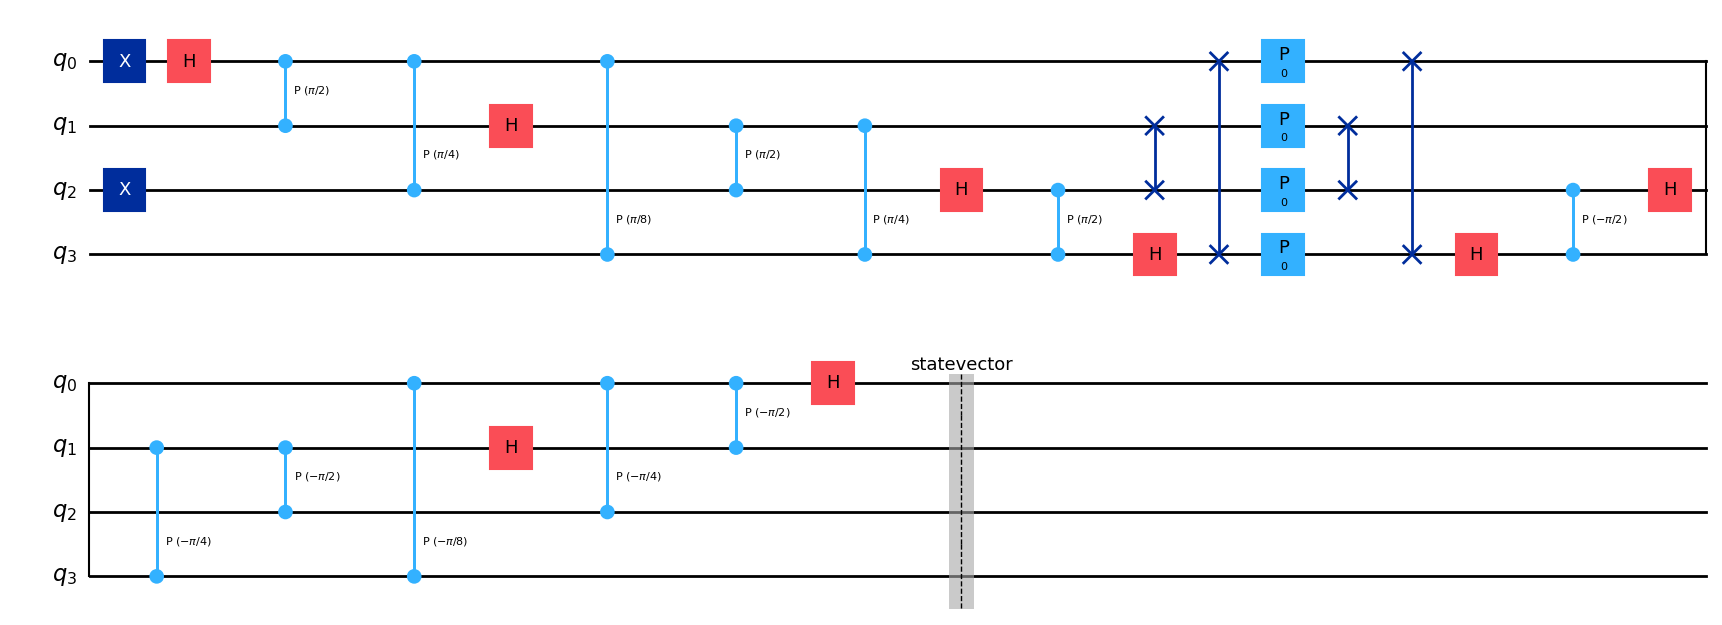

In [8]:
qc.draw("mpl")